<a href="https://colab.research.google.com/github/orangecat24/DiabetesPredictionMLAlgorithms/blob/main/DecisionTreesClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets
y = y['Diabetes_binary'].values
print("Class distribution in target variable:")
print(pd.Series(y).value_counts(normalize=True))
 #before splitting
print("Class distribution in original target variable:")
original_distribution = pd.Series(y).value_counts(normalize=True)
print(original_distribution)

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Class distribution in target variable:
0    0.860667
1    0.139333
Name: proportion, dtype: float64
Class distribution in original target variable:
0    0.860667
1    0.139333
Name: proportion, dtype: float64


Class distribution in training set before SMOTE:
0    0.860666
1    0.139334
Name: proportion, dtype: float64

Data successfully split into training and testing sets.
Training features shape: (202944, 21)
Testing features shape: (50736, 21)
Training labels shape: (202944,)
Testing labels shape: (50736,)
Class distribution in training set after SMOTE:
0    0.5
1    0.5
Name: proportion, dtype: float64


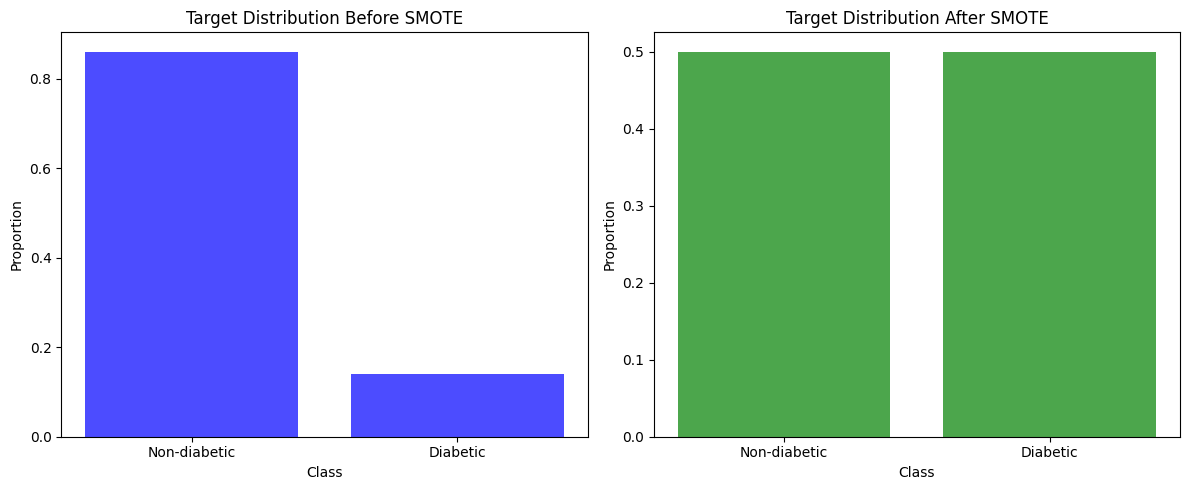

In [ ]:
print("Class distribution in training set before SMOTE:")
before_smote_distribution = pd.Series(y_train).value_counts(normalize=True)
print(before_smote_distribution)

print("\nData successfully split into training and testing sets.")
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)
# y_train = y_train.values.ravel()
# y_test = y_test.values.ravel()

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)


print("Class distribution in training set after SMOTE:")
after_smote_distribution = pd.Series(y_train_balanced).value_counts(normalize=True)
print(after_smote_distribution)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Before using SMOTE sampling
ax[0].bar(before_smote_distribution.index, before_smote_distribution.values, color='blue', alpha=0.7)
ax[0].set_title("Target Distribution Before SMOTE")
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Non-diabetic', 'Diabetic'])
ax[0].set_ylabel("Proportion")
ax[0].set_xlabel("Class")

# After SMOTE sampling
ax[1].bar(after_smote_distribution.index, after_smote_distribution.values, color='green', alpha=0.7)
ax[1].set_title("Target Distribution After SMOTE")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Non-diabetic', 'Diabetic'])
ax[1].set_ylabel("Proportion")
ax[1].set_xlabel("Class")

plt.tight_layout()
plt.show()

In [ ]:
max_depths = [3,7, None]   # None = no limit until all leaves are pure or min_samples_split is reached
min_samples_splits = [2,10,50]
min_samples_leafs = [1,2,4]

best_score_dt = 0
best_params_dt = None
best_classification_report_dt = ""
best_model_dt = None

# 8. Grid search over Decision Tree parameters
for depth in max_depths:
    for min_split in min_samples_splits:
        for min_leaf in min_samples_leafs:
            print(f"Training Decision Tree with parameters: max_depth={depth}, "
                  f"min_samples_split={min_split}, min_samples_leaf={min_leaf}")

            # Initialize the model
            dt_model = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                random_state=42
            )

            # Train the model
            dt_model.fit(X_train, y_train)

            # Predict on test set
            y_pred = dt_model.predict(X_test)

            # Evaluate the model
            accuracy = accuracy_score(y_test, y_pred)
            print(f"Decision Tree Accuracy with current parameters: {accuracy}\n")

            # Classification report
            classification_rep = classification_report(y_test, y_pred)
            print(f"Classification Report:\n{classification_rep}\n")

            # Track the best model
            if accuracy > best_score_dt:
                best_score_dt = accuracy
                best_params_dt = {
                    'max_depth': depth,
                    'min_samples_split': min_split,
                    'min_samples_leaf': min_leaf
                }
                best_classification_report_dt = classification_rep
                best_model_dt = dt_model

# 9. Display the best parameters and accuracy
print("Best Decision Tree Parameters:", best_params_dt)
print("Best Decision Tree Accuracy:", best_score_dt)
print("Best Classification Report:\n", best_classification_report_dt)

# 10. Visualize the best decision tree (up to depth=2)
if best_model_dt:
    plt.figure(figsize=(20, 10))
    plot_tree(
        best_model_dt,
        feature_names=X.columns,  # Ensure X is a DataFrame
        class_names=[str(cls) for cls in np.unique(y)],
        max_depth=2,  # Limit visualization depth
        filled=True,
        rounded=True
    )
    plt.title("Best Decision Tree Visualization (Up to Depth 2)")
    plt.show()

Training Decision Tree with parameters: max_depth=3, min_samples_split=2, min_samples_leaf=1
Decision Tree Accuracy with current parameters: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38


Training Decision Tree with parameters: max_depth=3, min_samples_split=2, min_samples_leaf=2
Decision Tree Accuracy with current parameters: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

<Figure size 2000x1000 with 0 Axes>

Using SMOTE AND PCA


Training Decision Tree with parameters: max_depth=3, min_samples_split=2, min_samples_leaf=1
Decision Tree Accuracy with current parameters: 0.6741367076631978

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.69      0.78     43667
           1       0.24      0.61      0.34      7069

    accuracy                           0.67     50736
   macro avg       0.58      0.65      0.56     50736
weighted avg       0.82      0.67      0.72     50736


Training Decision Tree with parameters: max_depth=3, min_samples_split=2, min_samples_leaf=2
Decision Tree Accuracy with current parameters: 0.6741367076631978

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.69      0.78     43667
           1       0.24      0.61      0.34      7069

    accuracy                           0.67     50736
   macro avg       0.58      0.65      0.56     50736
weighted avg       0.82      0.6

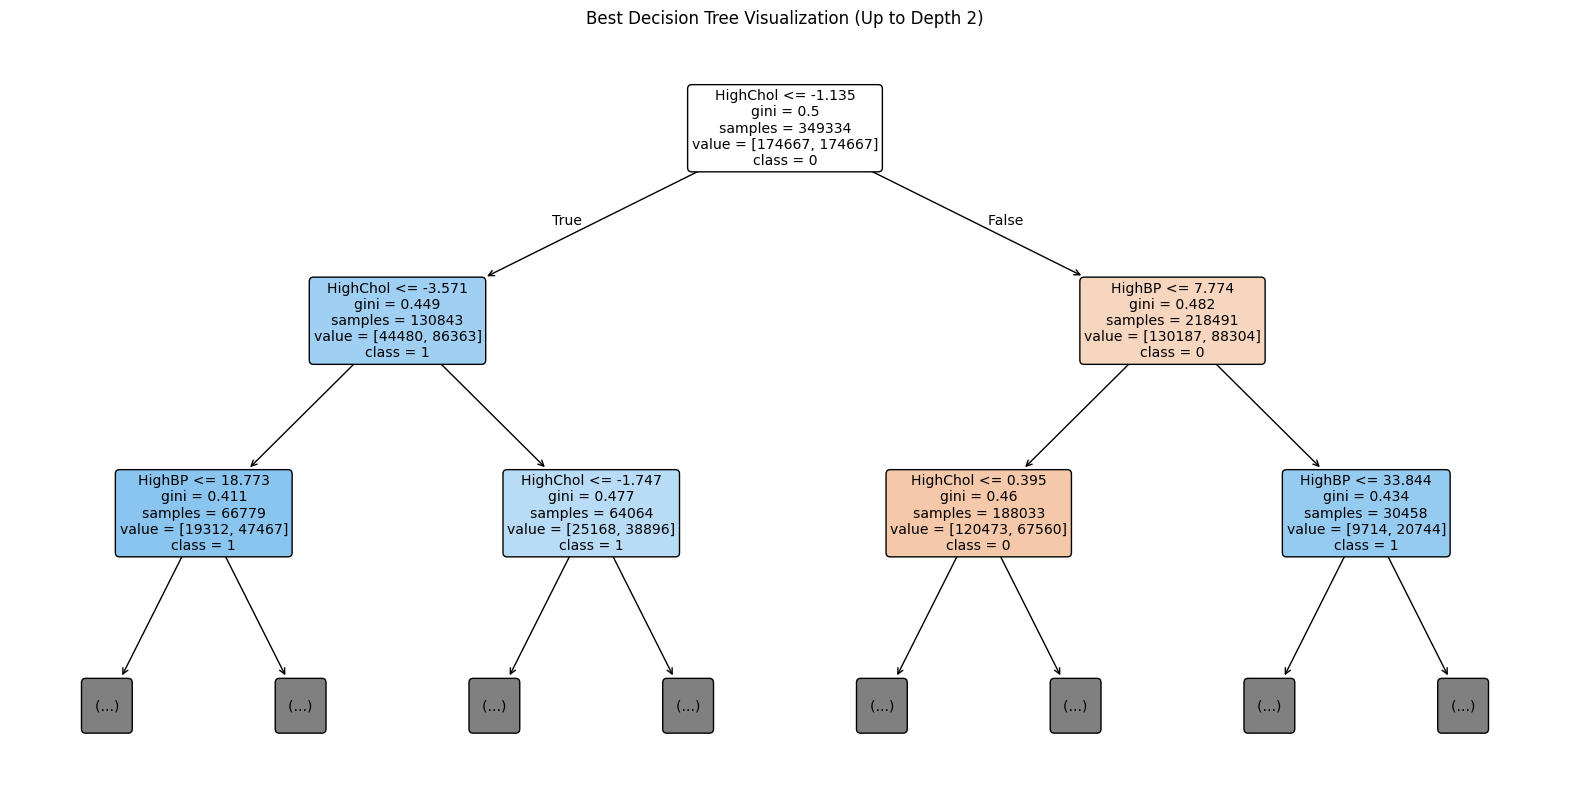

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_balanced)
X_test_pca = pca.transform(X_test)

max_depths = [3, 5, 7, None]   # None = no limit until all leaves are pure or min_samples_split is reached
min_samples_splits = [2, 3, 5]
min_samples_leafs = [1, 2, 4]

best_score_dt = 0
best_params_dt = None
best_classification_report_dt = ""
best_model_dt = None

# 8. Grid search over Decision Tree parameters
for depth in max_depths:
    for min_split in min_samples_splits:
        for min_leaf in min_samples_leafs:
            print(f"Training Decision Tree with parameters: max_depth={depth}, "
                  f"min_samples_split={min_split}, min_samples_leaf={min_leaf}")

            # Initialize the model
            dt_model = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                random_state=42
            )

            # Train the model
            dt_model.fit(X_train_pca, y_train_balanced)

            # Predict on test set
            y_pred = dt_model.predict(X_test_pca)

            # Evaluate the model
            accuracy = accuracy_score(y_test, y_pred)
            print(f"Decision Tree Accuracy with current parameters: {accuracy}\n")

            # Classification report
            classification_rep = classification_report(y_test, y_pred)
            print(f"Classification Report:\n{classification_rep}\n")

            # Track the best model
            if accuracy > best_score_dt:
                best_score_dt = accuracy
                best_params_dt = {
                    'max_depth': depth,
                    'min_samples_split': min_split,
                    'min_samples_leaf': min_leaf
                }
                best_classification_report_dt = classification_rep
                best_model_dt = dt_model

# 9. Display the best parameters and accuracy
print("Best Decision Tree Parameters:", best_params_dt)
print("Best Decision Tree Accuracy:", best_score_dt)
print("Best Classification Report:\n", best_classification_report_dt)

# 10. Visualize the best decision tree (up to depth=2)
if best_model_dt:
    plt.figure(figsize=(20, 10))
    plot_tree(
        best_model_dt,
        feature_names=X.columns,  # Ensure X is a DataFrame
        class_names=[str(cls) for cls in np.unique(y)],
        max_depth=2,  # Limit visualization depth
        filled=True,
        rounded=True
    )
    plt.title("Best Decision Tree Visualization (Up to Depth 2)")
    plt.show()